
[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Raw df shape: (1590, 5)
MultiIndex([('ABW',    'FP.CPI.TOTL.ZG'),
            ('ABW',    'NE.GDI.TOTL.ZS'),
            ('ABW',    'NE.TRD.GNFS.ZS'),
            ('ABW', 'NY.GDP.MKTP.KD.ZG'),
            ('ABW',    'NY.GDP.PCAP.CD'),
            ('ABW',    'SL.UEM.TOTL.ZS'),
            ('AFE',    'FP.CPI.TOTL.ZG'),
            ('AFE',    'NE.GDI.TOTL.ZS'),
            ('AFE',    'NE.TRD.GNFS.ZS'),
            ('AFE', 'NY.GDP.MKTP.KD.ZG')],
           names=['economy', 'series'])
Countries only shape: (217, 9)
Wide df shape: (265, 30)
Clean df shape: (265, 6)
Final usable countries: (156, 9)
(156, 6)


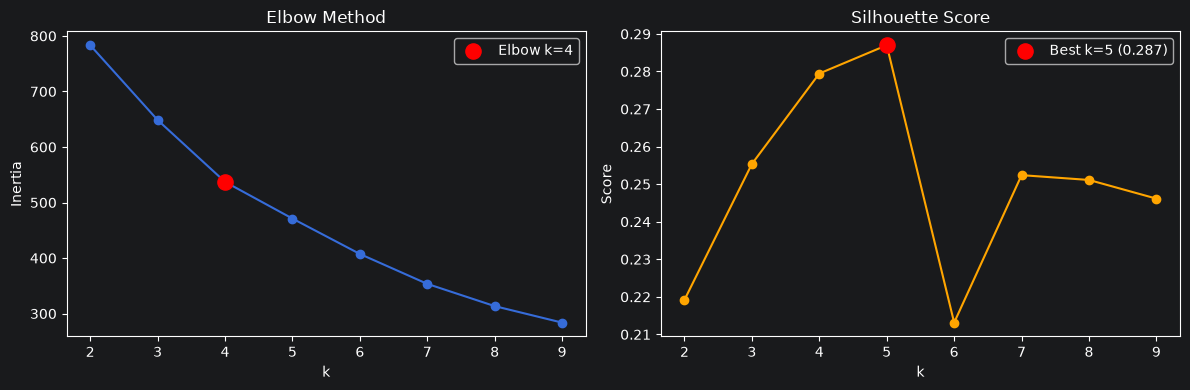

Silhouette scores by k: [(2, 0.2192051624734713), (3, 0.2553818955185174), (4, 0.279458200559923), (5, 0.2869975485148117), (6, 0.21313320064338173), (7, 0.25239999241810834), (8, 0.25111773792891895), (9, 0.2461476252238284)]
Elbow method suggests k = 4
Silhouette method suggests k = 5 (score = 0.287)

Using k_final = 4
cluster
1    101
0     33
3     18
2      4
Name: count, dtype: int64
Explained variance ratio: [0.27196238 0.23803279]
Total variance captured: 0.5099951683412792


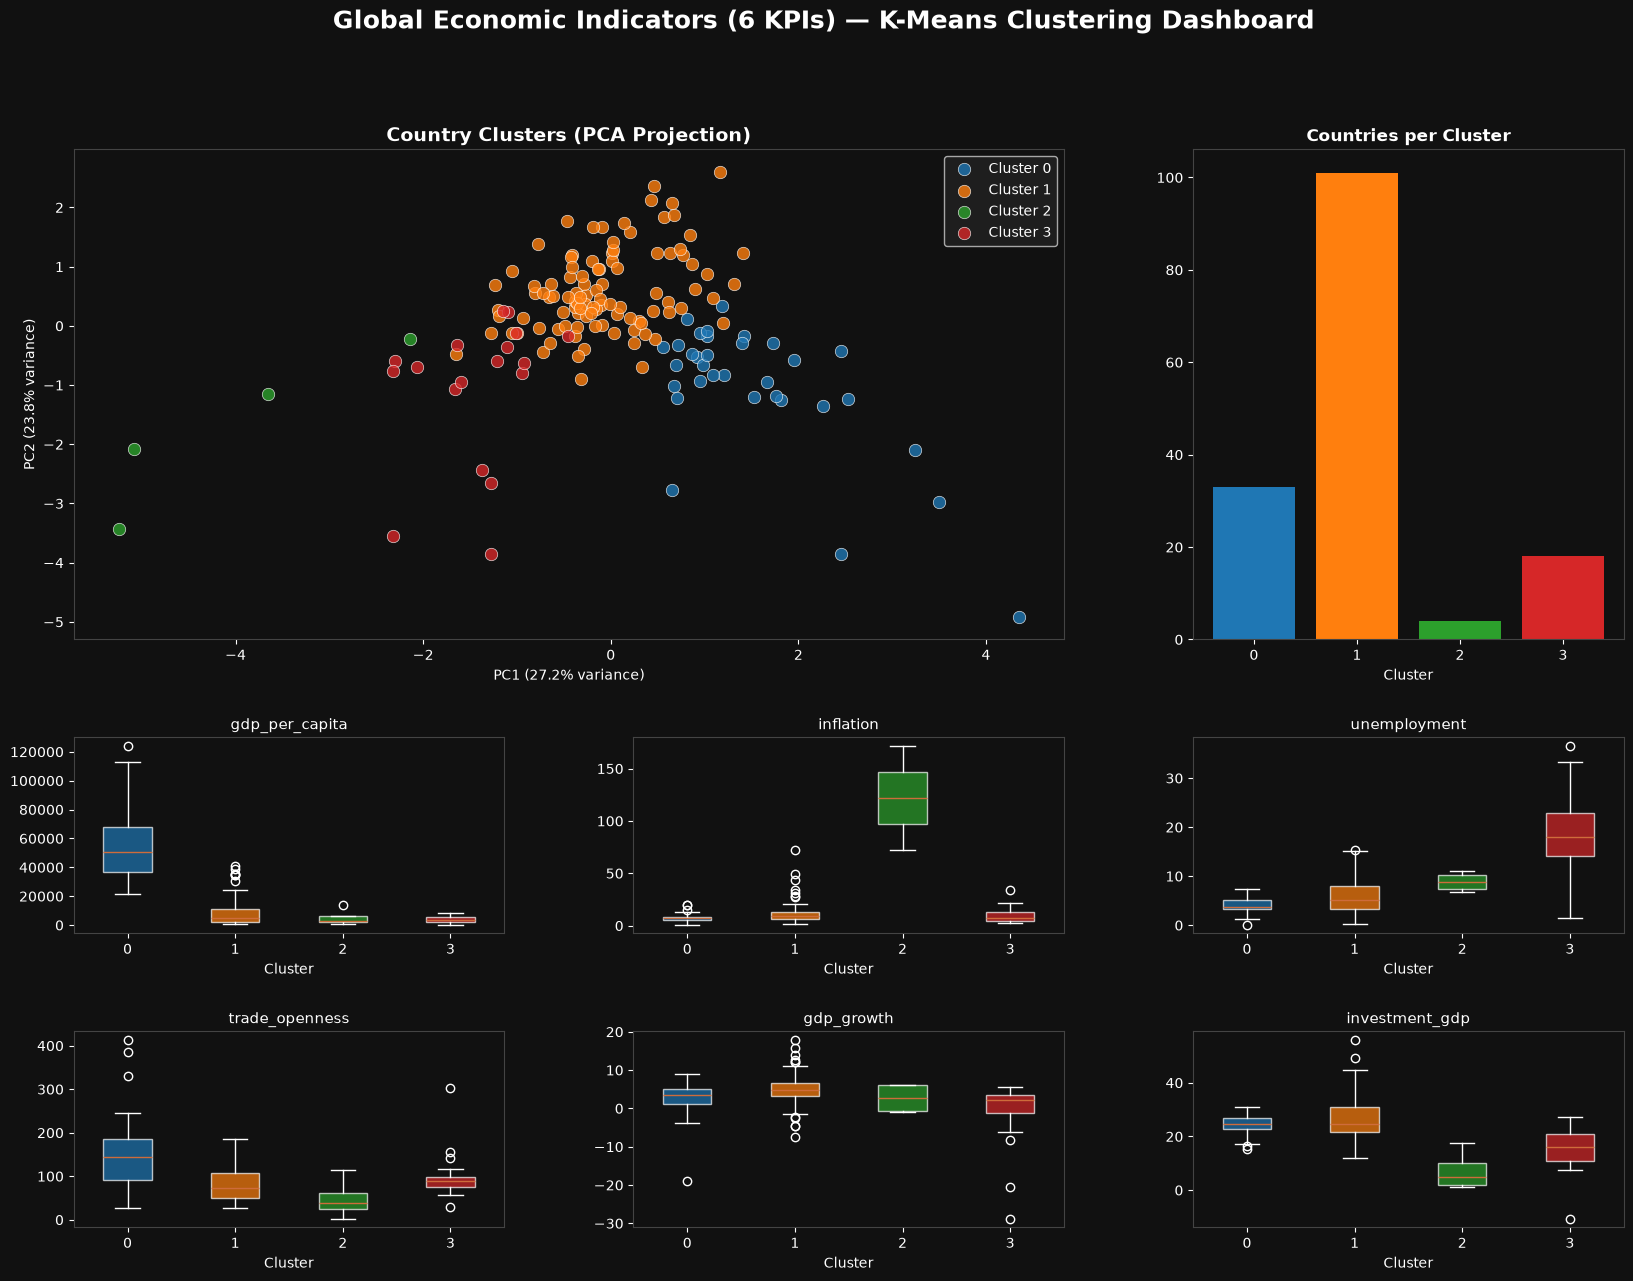


=== Feature-level outliers (|z| > 3 on >=1 KPI): 16 countries ===
  Bhutan: {'investment_gdp': 3.64}
  Switzerland: {'gdp_per_capita': 3.23}
  Djibouti: {'unemployment': 3.28, 'trade_openness': 3.24, 'investment_gdp': -4.05}
  Hong Kong SAR, China: {'trade_openness': 4.56}
  Ireland: {'gdp_per_capita': 3.53}
  Lebanon: {'inflation': 7.69}
  Luxembourg: {'gdp_per_capita': 4.28, 'trade_openness': 4.99}
  Macao SAR, China: {'gdp_growth': -4.24}
  Norway: {'gdp_per_capita': 3.85}
  Sudan: {'inflation': 6.12}
  Singapore: {'trade_openness': 3.69}
  Eswatini: {'unemployment': 5.02}
  Timor-Leste: {'gdp_growth': -4.53}
  Ukraine: {'gdp_growth': -6.07}
  South Africa: {'unemployment': 4.47}
  Zimbabwe: {'inflation': 4.46}

=== Countries far from their own cluster centroid (>2 std above mean): 8 ===
                         name  cluster  dist_to_centroid  gdp_per_capita  \
economy                                                                    
UKR                   Ukraine        3       

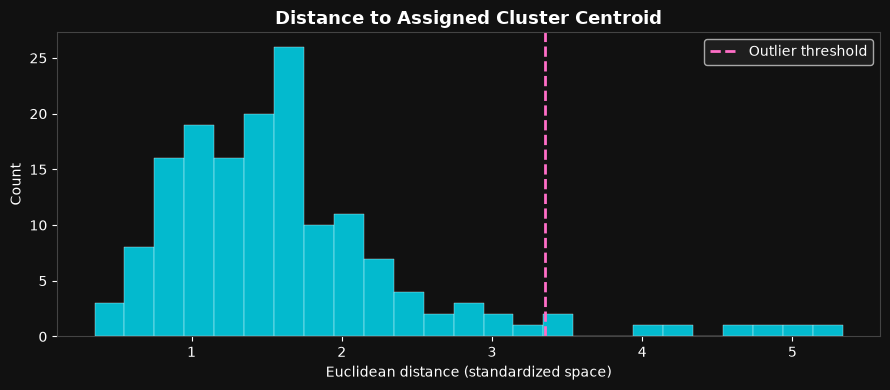


=== Cluster profiles (mean KPI value per cluster, raw units) ===
         gdp_per_capita  inflation  unemployment  trade_openness  gdp_growth  \
cluster                                                                        
0              56855.29       7.61          4.11          155.05        2.75   
1               8567.51      11.14          5.95           81.78        5.04   
2               5299.80     121.79          8.88           48.20        2.65   
3               4112.24      10.21         18.15          101.31       -1.46   

         investment_gdp  n_countries  
cluster                               
0                 24.31           33  
1                 26.64          101  
2                  7.11            4  
3                 15.42           18  

=== PCA loadings ===
                  PC1    PC2
gdp_per_capita  0.550 -0.382
inflation      -0.480 -0.200
unemployment   -0.348 -0.124
trade_openness  0.433 -0.499
gdp_growth      0.181  0.483
investment_gdp  0.354  

In [3]:
# ============================================================
# STEP 0: Install and import libraries
# ============================================================
# installs the World Bank API client into this environment (not built into Python)
# NOTE: comment moved to its own line above -- on Windows (cmd.exe), a comment on
# the SAME line as "!pip install ..." gets passed to pip as a literal argument
# (pip tries to install a package called "#" and errors out). Bash-based shells
# don't have this problem, but cmd.exe does, so keep pip install lines comment-free.
!pip install wbgapi --break-system-packages
import wbgapi as wb          # import it under the short alias "wb" so we can write wb.data / wb.economy instead of the full name
import pandas as pd          # pandas = table/dataframe library, gives us .DataFrame, .merge, .groupby etc.
import numpy as np           # numpy = numeric array library, used below for math like norms, means, std devs

# ============================================================
# STEP 1: Define indicators and pull raw data from World Bank API
# ============================================================
indicators = {                          # a Python dict: keys are World Bank indicator codes, values are our friendlier column names
    'NY.GDP.PCAP.CD': 'gdp_per_capita', # code for "GDP per capita, current US$"
    'FP.CPI.TOTL.ZG': 'inflation',      # code for "Inflation, consumer prices (annual %)"
    'SL.UEM.TOTL.ZS': 'unemployment',   # code for "Unemployment, total (% of labor force)"
    'NE.TRD.GNFS.ZS': 'trade_openness', # code for "Trade (% of GDP)" = (imports+exports)/GDP
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',  # code for "GDP growth (annual %)"
    'NE.GDI.TOTL.ZS': 'investment_gdp'  # code for "Gross capital formation (% of GDP)"
}                                        # end of dict definition

# wb.data.DataFrame(...) calls the World Bank API and returns a table
df = wb.data.DataFrame(list(indicators.keys()), time=range(2018, 2023))
# list(indicators.keys()) turns the dict keys into a plain list of indicator codes to request
# time=range(2018, 2023) requests years 2018,2019,2020,2021,2022 (range() stops one before the end)
print("Raw df shape:", df.shape)   # .shape returns (n_rows, n_columns) as a tuple, just for a sanity check print
print(df.index[:10])               # df.index is the row labels; [:10] slices the first 10 to preview them

# ============================================================
# STEP 2: Get country metadata, filter out regional aggregates
# ============================================================
econ_info = wb.economy.DataFrame()                       # pulls a metadata table: one row per "economy" code, with name/region/income/aggregate flag
countries_only = econ_info[econ_info['aggregate'] == False]  # boolean filter: econ_info['aggregate']==False makes a True/False mask, and econ_info[mask] keeps only True rows (real countries, not aggregates like "World")
print("Countries only shape:", countries_only.shape)     # confirm how many actual countries we have metadata for

# ============================================================
# STEP 3: Pivot 'series' out of the row index into columns
# ============================================================
# df currently has a MultiIndex (economy, series) on the rows and years as columns.
# unstack('series') moves the 'series' level of the row index into the columns instead,
# so we end up with: rows = economy, columns = (series, year) pairs
df_wide = df.unstack('series')
print("Wide df shape:", df_wide.shape)   # print the new shape after reshaping

# ============================================================
# STEP 4: Collapse each indicator to "most recent non-null value"
# ============================================================
clean_df = pd.DataFrame(index=df_wide.index)   # start an empty dataframe that will share the same row labels (economy codes) as df_wide

for code, name in indicators.items():                    # loop through each (code, friendly_name) pair in our dict, one indicator at a time
    sub = df_wide.xs(code, axis=1, level='series')        # .xs() = "cross-section": pulls out just the columns belonging to this indicator code, axis=1 means we're slicing columns, level='series' tells it which index level to match on
    sub = sub[sorted(sub.columns, reverse=True)]          # sorted(..., reverse=True) sorts the year column labels descending, so column 0 becomes the newest year
    # sub.bfill(axis=1) = "backward fill" across columns (axis=1 means row-wise, left to right):
    # if a cell is NaN, it gets replaced by the next non-null value found to its right (an older year)
    # .iloc[:, 0] then grabs column position 0 (the newest year slot) for every row,
    # which after bfill holds either the real newest value, or the nearest older year's value as a fallback
    clean_df[name] = sub.bfill(axis=1).iloc[:, 0]         # assign the resulting single column into clean_df under our friendly name

print("Clean df shape:", clean_df.shape)   # confirm shape: should be (n_economies, 6) - one column per KPI
clean_df.head(10)                          # .head(10) previews the first 10 rows (Jupyter/Colab will display this automatically)

# ============================================================
# STEP 5: Merge with country metadata (name, region, income level)
# ============================================================
merged = clean_df.merge(                                 # .merge() joins two dataframes together, like a SQL JOIN
    countries_only[['name', 'region', 'incomeLevel']],    # select only these 3 columns from the metadata table
    left_index=True, right_index=True,                    # tells pandas to join using the row index (economy code) on both sides, instead of a named column
    how='inner'                                            # 'inner' = keep only rows whose economy code exists in BOTH tables
)

# ============================================================
# STEP 6: Drop any country missing one or more indicator values
# ============================================================
feature_cols = list(indicators.values())          # grabs just the 6 friendly column names (the dict values) into a list; reused everywhere below so we don't retype them
final_df = merged.dropna(subset=feature_cols)      # .dropna(subset=...) removes any row that has a NaN in ANY of the listed columns; k-means requires fully numeric, non-missing input
print("Final usable countries:", final_df.shape)   # how many countries survived the missing-data filter
final_df.head(10)                                   # preview

# ============================================================
# STEP 7: Standardize the 6 numeric features
# ============================================================
# k-means measures distance between points -- without rescaling, GDP per capita
# (values like 50,000) would swamp unemployment (values like 5) in the distance
# calculation, even though both should matter equally.
from sklearn.preprocessing import StandardScaler   # import the scaling tool from scikit-learn

X = final_df[feature_cols].values      # select the 6 KPI columns and convert from a dataframe to a raw numpy array (.values strips row/column labels)
scaler = StandardScaler()              # create a scaler object; it will learn each column's mean and standard deviation
X_scaled = scaler.fit_transform(X)     # .fit_transform() = learn the mean/std from X, then immediately rescale X using them, so every column ends up with mean≈0, std≈1
print(X_scaled.shape)                  # should still be (n_countries, 6), just rescaled now

# ============================================================
# STEP 8: Elbow method + silhouette score to pick k
# ============================================================
from sklearn.cluster import KMeans                 # the clustering algorithm itself
from sklearn.metrics import silhouette_score        # a metric that scores how well-separated clusters are
import matplotlib.pyplot as plt                      # plotting library, aliased as plt by convention

inertias, silhouettes = [], []   # two empty lists we'll fill in the loop below: inertias = compactness scores, silhouettes = separation scores
k_range = range(2, 10)           # the set of k (cluster count) values we'll test: 2,3,4,5,6,7,8,9

for k in k_range:                                            # try each candidate k value one at a time
    km = KMeans(n_clusters=k, random_state=42, n_init=10)    # create a KMeans model: n_clusters=k sets how many clusters to find, random_state=42 makes results reproducible (same "random" starting points every run), n_init=10 means it tries 10 different random starts and keeps the best one
    labels = km.fit_predict(X_scaled)                         # .fit_predict() fits the model to the data AND returns which cluster (0,1,2,...) each row was assigned to, in one step
    inertias.append(km.inertia_)                              # km.inertia_ is a built-in attribute: sum of squared distances from each point to its assigned cluster center (lower = tighter clusters); .append() adds it to our list
    silhouettes.append(silhouette_score(X_scaled, labels))    # compute the silhouette score for this k's clustering and store it too

# --- auto-detect the elbow point: the k whose point sits farthest
# (perpendicular distance) from the straight line connecting the
# curve's first point and last point
k_list = list(k_range)                                    # convert the range object into an actual list so we can index into it
p1, p2 = np.array([k_list[0], inertias[0]]), np.array([k_list[-1], inertias[-1]])  # p1 = the curve's first (k, inertia) point as a numpy array, p2 = the last point; k_list[-1] means "last element"
line_vec = p2 - p1                                        # the vector pointing from p1 to p2 (straightforward vector subtraction)
line_vec_norm = line_vec / np.linalg.norm(line_vec)       # np.linalg.norm() computes the vector's length; dividing by its own length gives a "unit vector" (length 1, same direction)
elbow_dists = []                                          # will hold, for every k, how far that point is from the straight line p1-p2
for k, inertia in zip(k_list, inertias):                  # zip() pairs up k_list and inertias element-by-element so we loop over both together
    p = np.array([k, inertia])                            # this candidate point as a numpy array
    proj_len = np.dot(p - p1, line_vec_norm)              # np.dot() = dot product; this gives how far along the line direction this point's projection falls
    proj_point = p1 + proj_len * line_vec_norm            # the actual coordinates of that projected point, sitting on the line
    elbow_dists.append(np.linalg.norm(p - proj_point))    # perpendicular distance = straight-line distance between the real point and its projection onto the line
elbow_k = k_list[int(np.argmax(elbow_dists))]             # np.argmax() returns the INDEX of the largest value in the list; we use that index to look up which k it corresponds to -- that k is the "elbow"

best_sil_k = k_list[int(np.argmax(silhouettes))]  # same trick: index of the highest silhouette score, converted back into the actual k value
best_sil_score = max(silhouettes)                  # the highest silhouette score itself, for display

fig, axes = plt.subplots(1, 2, figsize=(12, 4))    # create a figure with 1 row, 2 columns of subplots (side-by-side), 12x4 inches; axes is an array of 2 subplot objects
axes[0].plot(k_list, inertias, marker='o')          # left subplot: line plot of inertia vs k, marker='o' puts a circle at each data point
axes[0].scatter([elbow_k], [inertias[k_list.index(elbow_k)]],   # overlay a single red dot at the detected elbow point; k_list.index(elbow_k) finds elbow_k's position in the list so we can look up its matching inertia value
                 color='red', s=120, zorder=5, label=f'Elbow k={elbow_k}')   # s=120 sets marker size, zorder=5 draws it above the line, label= sets the legend text (f-string inserts the elbow_k value)
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].legend()   # chain several formatting calls on one line: title, axis labels, and show the legend

axes[1].plot(k_list, silhouettes, marker='o', color='orange')   # right subplot: silhouette score vs k
axes[1].scatter([best_sil_k], [best_sil_score], color='red', s=120, zorder=5,   # mark the best (highest) silhouette point in red
                 label=f'Best k={best_sil_k} ({best_sil_score:.3f})')            # :.3f formats the score to 3 decimal places in the label text
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Score'); axes[1].legend()   # formatting for the right subplot

plt.tight_layout(); plt.show()   # tight_layout() auto-adjusts spacing so labels don't overlap; show() actually renders the figure
print("Silhouette scores by k:", list(zip(k_list, silhouettes)))   # print every (k, score) pair as a list of tuples
print(f"Elbow method suggests k = {elbow_k}")                       # f-string: {elbow_k} gets substituted with its value
print(f"Silhouette method suggests k = {best_sil_k} (score = {best_sil_score:.3f})")

# ============================================================
# STEP 9: Final K-means (set k_final using the plots above)
# ============================================================
k_final = 4   # <-- changed from 3 to 4: elbow independently suggested 4, and it's silhouette's near-best score (0.279 vs the 0.287 peak at k=5); see FINDINGS at the bottom. RE-RUN THE WHOLE NOTEBOOK after this change -- cluster sizes, centroid_table, and outlier lists will all shift, and the written FINDINGS below describe the OLD k=3 run until you paste me new output.
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)   # build the final model using our chosen k
final_df = final_df.copy()                              # .copy() makes an independent copy of final_df; without this, adding a new column below could trigger a pandas "SettingWithCopyWarning" since final_df was sliced from merged
final_df['cluster'] = km_final.fit_predict(X_scaled)     # fit the model and store each country's assigned cluster number as a new column

print(f"\nUsing k_final = {k_final}")                     # \n prints a blank line first for readability
print(final_df['cluster'].value_counts())                # .value_counts() counts how many rows fall into each unique cluster label
final_df[['name', 'incomeLevel', 'cluster'] + feature_cols].head(15)   # select these specific columns (list + list concatenation) and preview 15 rows

# ============================================================
# STEP 10: Dashboard -- PCA plot, cluster sizes, feature breakdowns
# ============================================================
from sklearn.decomposition import PCA   # PCA = Principal Component Analysis, used to compress many features into 2D for plotting

pca = PCA(n_components=2)                   # create a PCA object that will reduce our 6 dimensions down to just 2
X_pca = pca.fit_transform(X_scaled)         # fit PCA on the scaled data and transform it into 2D coordinates in one step
final_df['pca1'], final_df['pca2'] = X_pca[:, 0], X_pca[:, 1]   # X_pca[:, 0] takes every row's first column (PC1 coordinate); tuple assignment sets both new columns at once
print("Explained variance ratio:", pca.explained_variance_ratio_)   # built-in attribute: fraction of total variance each of the 2 components captures
print("Total variance captured:", sum(pca.explained_variance_ratio_))   # sum() adds PC1 + PC2's ratios together for a combined total

cmap = plt.get_cmap('tab10')                            # loads matplotlib's built-in "tab10" palette, a set of 10 visually distinct colors
cluster_colors = [cmap(i) for i in range(k_final)]       # list comprehension: calls cmap(i) for i=0,1,...,k_final-1 to get one color per cluster, scales automatically instead of a fixed hardcoded list

fig = plt.figure(figsize=(20, 14))          # create a blank figure, 20x14 inches, big enough to hold multiple subplots
fig.patch.set_facecolor('#111111')          # sets the figure's background color to a near-black hex code
gs = fig.add_gridspec(4, 3, hspace=0.5, wspace=0.3)      # defines an invisible 4-row by 3-column grid we can place subplots into; hspace/wspace control vertical/horizontal spacing between them

# Panel 1: PCA scatter, occupies rows 0-1, cols 0-1 (top-left 2x2 block)
ax1 = fig.add_subplot(gs[0:2, 0:2])         # gs[0:2, 0:2] means "rows 0 through 1, columns 0 through 1" -- this subplot spans a 2x2 block of the grid
ax1.set_facecolor('#111111')                # dark background for this individual subplot too
for c in sorted(final_df['cluster'].unique()):                 # .unique() gets each distinct cluster label present; sorted() puts them in order 0,1,2,...
    sub = final_df[final_df['cluster'] == c]                    # filter final_df down to just this cluster's rows
    ax1.scatter(sub['pca1'], sub['pca2'], label=f'Cluster {c}', # plot this cluster's points; label= controls what shows in the legend
                color=cluster_colors[c], s=80, alpha=0.8, edgecolor='white', linewidth=0.5)   # color from our list, s=80 dot size, alpha=0.8 slight transparency, white outline around each dot
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', color='white')   # x-axis label shows what % of variance PC1 explains, *100 converts fraction to percent
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', color='white')   # same for y-axis/PC2
ax1.set_title('Country Clusters (PCA Projection)', color='white', fontsize=14, fontweight='bold')   # subplot title styling
ax1.legend(facecolor='#222222', labelcolor='white')     # show the legend box with a dark background and white text
ax1.tick_params(colors='white')                          # make the axis tick numbers white (visible against the dark background)
for spine in ax1.spines.values(): spine.set_color('#444444')   # spines are the subplot's border lines; loop through all 4 (top/bottom/left/right) and color them dark gray

# Panel 2: cluster sizes, occupies rows 0-1, col 2 (top-right, same height as Panel 1
# so nothing below it in rows 0-1 overlaps -- the boxplot loop below starts at row 2)
ax2 = fig.add_subplot(gs[0:2, 2])           # spans rows 0-1, just column 2 (single column, double height to match Panel 1)
ax2.set_facecolor('#111111')
counts = final_df['cluster'].value_counts().sort_index()   # count rows per cluster, then .sort_index() orders the result by cluster number instead of by count size
ax2.bar(counts.index.astype(str), counts.values, color=cluster_colors[:len(counts)])   # bar chart; .astype(str) converts cluster numbers to text labels for the x-axis; slice the color list to match how many bars we have
ax2.set_title('Countries per Cluster', color='white', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cluster', color='white')
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_color('#444444')

# Panels 3-8: 6 feature boxplots, rows 2-3 (below the panels above, no overlap), 3 per row
for i, feat in enumerate(feature_cols):                 # enumerate() gives us both the index i (0-5) and the feature name in each loop iteration
    row, col = 2 + i // 3, i % 3                        # integer division i//3 and modulo i%3 together turn a flat 0-5 index into a (row, col) grid position: i=0,1,2 -> row2,col0/1/2; i=3,4,5 -> row3,col0/1/2
    ax = fig.add_subplot(gs[row, col])                  # place this subplot at the computed grid cell
    ax.set_facecolor('#111111')
    data_by_cluster = [final_df[final_df['cluster'] == c][feat].values    # list comprehension: for each cluster c, grab this feature's values as a numpy array
                        for c in sorted(final_df['cluster'].unique())]     # loop over sorted cluster labels
    bp = ax.boxplot(data_by_cluster, patch_artist=True,                   # draw a boxplot; patch_artist=True lets us fill the boxes with color (otherwise they'd be outline-only)
                     tick_labels=[str(c) for c in sorted(final_df['cluster'].unique())])   # label each box with its cluster number as a string
    for patch, color in zip(bp['boxes'], cluster_colors):    # bp['boxes'] is the list of box shapes matplotlib drew; pair each one with a color from our list
        patch.set_facecolor(color); patch.set_alpha(0.7)     # fill each box with its cluster's color, slightly transparent
    ax.set_title(feat, color='white', fontsize=11)            # title this subplot with the KPI's column name
    ax.set_xlabel('Cluster', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_color('#444444')

fig.suptitle('Global Economic Indicators (6 KPIs) — K-Means Clustering Dashboard',   # suptitle = a title for the WHOLE figure, above all subplots
             color='white', fontsize=18, fontweight='bold', y=0.98)                   # y=0.98 nudges it near the very top of the figure
plt.show()   # render everything

# ============================================================
# STEP 11: OUTLIER DETECTION
# ============================================================

# --- 11a. feature-level z-score outliers: any country extreme (|z|>3) on a single KPI ---
z_scores = pd.DataFrame(X_scaled, columns=feature_cols, index=final_df.index)  # rebuild the standardized values as a labeled dataframe (X_scaled was a plain numpy array) so we can reference countries by name/index again
outlier_mask = z_scores.abs() > 3                          # .abs() takes the absolute value of every cell; > 3 compares each to 3, producing a True/False grid the same shape as z_scores
feature_outliers = final_df.loc[outlier_mask.any(axis=1), ['name'] + feature_cols].copy()   # outlier_mask.any(axis=1) is True for any ROW that has at least one True value across its columns; .loc[...] uses that to select matching rows from final_df

print(f"\n=== Feature-level outliers (|z| > 3 on >=1 KPI): {len(feature_outliers)} countries ===")   # len() counts how many rows are in feature_outliers
for idx in feature_outliers.index:                                       # loop over the row labels (economy codes) of the flagged countries
    flagged = outlier_mask.loc[idx]                                      # get this specific country's True/False row from the mask
    flagged_feats = z_scores.loc[idx, flagged].round(2).to_dict()        # z_scores.loc[idx, flagged] selects only the columns that were True for this row; .round(2) rounds to 2 decimals; .to_dict() converts to a plain {feature: value} dict for easy printing
    print(f"  {final_df.loc[idx, 'name']}: {flagged_feats}")             # look up the country's readable name and print it with its flagged values

# --- 11b. multivariate distance-from-own-centroid outliers (borderline cluster members) ---
centroids = km_final.cluster_centers_                                    # built-in attribute: the (k_final x 6) array of each cluster's center coordinates in standardized space
dists = np.linalg.norm(X_scaled - centroids[final_df['cluster'].values], axis=1)
# centroids[final_df['cluster'].values]: for every row, look up ITS OWN cluster's centroid coordinates (fancy/advanced indexing using the cluster label as a lookup index)
# X_scaled - (that array) subtracts each row's own centroid from itself, elementwise
# np.linalg.norm(..., axis=1) computes the Euclidean length of each row's resulting difference vector = distance from that country to its own cluster's center
final_df['dist_to_centroid'] = dists                                     # store this distance as a new column

dist_threshold = final_df['dist_to_centroid'].mean() + 2 * final_df['dist_to_centroid'].std()   # threshold = mean distance + 2 standard deviations; a common statistical rule of thumb for flagging outliers
centroid_outliers = final_df[final_df['dist_to_centroid'] > dist_threshold][   # filter to rows whose distance exceeds the threshold
    ['name', 'cluster', 'dist_to_centroid'] + feature_cols                     # then select just these columns to display
].sort_values('dist_to_centroid', ascending=False)                             # sort so the most extreme outlier appears first

print(f"\n=== Countries far from their own cluster centroid (>2 std above mean): {len(centroid_outliers)} ===")
print(centroid_outliers)   # print the whole resulting table

fig, ax = plt.subplots(figsize=(9, 4))               # a fresh single-subplot figure for the histogram
fig.patch.set_facecolor('#111111'); ax.set_facecolor('#111111')   # dark backgrounds again
ax.hist(final_df['dist_to_centroid'], bins=25, color='#00e5ff', alpha=0.8, edgecolor='white', linewidth=0.3)
# .hist() draws a histogram; bins=25 splits the value range into 25 buckets and counts how many countries fall in each
ax.axvline(dist_threshold, color='#ff6ec7', linestyle='--', linewidth=2, label='Outlier threshold')
# axvline draws a single vertical dashed line at the threshold value, for visual reference
ax.set_title('Distance to Assigned Cluster Centroid', color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Euclidean distance (standardized space)', color='white')
ax.set_ylabel('Count', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#222222', labelcolor='white')
for spine in ax.spines.values(): spine.set_color('#444444')
plt.tight_layout(); plt.show()

# ============================================================
# STEP 12: PATTERN ANALYSIS
# ============================================================

# --- 12a. cluster centroid table in RAW units (lets you "name" clusters) ---
centroid_table = final_df.groupby('cluster')[feature_cols].mean().round(2)   # .groupby('cluster') groups rows by cluster label; [feature_cols] selects just the 6 KPI columns from each group; .mean() averages them within each group; .round(2) for readability
centroid_table['n_countries'] = final_df.groupby('cluster').size()           # .size() counts rows per group (cluster); attach as a new column alongside the averages
print("\n=== Cluster profiles (mean KPI value per cluster, raw units) ===")
print(centroid_table)

# --- 12b. PCA loadings: which KPIs drive each principal component ---
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=feature_cols).round(3)
# pca.components_ is a (2 x 6) array (2 components, 6 original features); .T transposes it to (6 x 2)
# so each ROW becomes one original KPI and each COLUMN is PC1/PC2 -- i.e. how much that KPI contributes to each component
print("\n=== PCA loadings ===")
print(loadings)

# --- 12c. country with the highest value in each KPI ---
print("\n=== Country with the highest value in each KPI ===")
top_per_kpi = {}                                      # empty dict to collect results as we loop, keyed by KPI name
for feat in feature_cols:                              # loop through each of the 6 KPI column names
    top_idx = final_df[feat].idxmax()                  # .idxmax() returns the ROW LABEL (not the value) where this column is at its maximum
    top_per_kpi[feat] = (final_df.loc[top_idx, 'name'], final_df.loc[top_idx, feat])   # store a tuple of (country name, that max value) using the row label to look both up
    print(f"  {feat}: {top_per_kpi[feat][0]} ({top_per_kpi[feat][1]:.2f})")            # [0] grabs the name, [1] grabs the value from the tuple we just stored

# ============================================================
# FINDINGS — from the real k_final=4 run (elbow's suggested k),
# replacing the earlier k=3 pass. Update manually if you rerun with
# a different k or indicator set.
# ============================================================
#
# DATA COVERAGE
# - 217 countries had metadata; after requiring complete data on all
#   6 KPIs, 156 remained (~28% dropped, mostly small/conflict-
#   affected states with reporting gaps -- a real limitation, results
#   skew toward better-tracked economies).
#
# WHY k=4 (AND WHAT CHANGED FROM k=3)
# - k=4 matches the elbow method exactly and is silhouette's
#   second-best score (0.279, barely behind k=5's 0.287).
# - Going from k=3 -> k=4 didn't touch the "advanced economy" cluster
#   (still 33 countries, same centroid) or the giant "emerging" middle
#   cluster (still 101 countries, virtually unchanged). What it DID do
#   is split the old single "crisis" cluster (22 countries) into two
#   clearly different kinds of crisis:
#     - Cluster 2 (4 countries): defined by HYPERINFLATION -- average
#       inflation 121.8%, everything else close to typical. These are
#       likely Lebanon, Sudan, Zimbabwe, and one more hyperinflation
#       case -- countries where currency collapse is the dominant
#       story, not weak growth or joblessness per se.
#     - Cluster 3 (18 countries): defined by HIGH UNEMPLOYMENT (18.15%
#       avg) and the only NEGATIVE average growth (-1.46%), but
#       inflation is unremarkable (10.2%, close to Cluster 1's level).
#   This is a real, meaningful split, not noise -- it confirms elbow
#   and silhouette were right that k=3 was averaging together two
#   distinct problems (currency crises vs. structural unemployment/
#   stagnation) into one blurry "distressed economies" bucket.
#
# THE 4 CLUSTERS AND WHAT THEY REPRESENT
# - Cluster 0 -- "Advanced / trade-hub" (33 countries): highest
#   GDP/capita (~$56,855) and highest trade openness (155% of GDP --
#   trade volume exceeding the whole economy, typical of small open
#   economies/financial hubs). Growth is modest (2.75%), normal for
#   already-developed economies.
# - Cluster 1 -- "Emerging / growth-stage" (101 countries, the clear
#   majority): mid GDP/capita (~$8,568), moderate inflation (11.1%)
#   and unemployment (6.0%), HIGHEST average growth (5.04%) and
#   investment (26.6% of GDP). Still the least tightly defined
#   cluster by far (2/3 of all countries) -- if you push to k=5 next,
#   this is almost certainly what would split further.
# - Cluster 2 -- "Hyperinflation crisis" (4 countries, smallest
#   group): average inflation 121.8% dwarfs every other cluster;
#   income (~$5,300) and growth (2.65%) are otherwise unremarkable.
#   A narrow, extreme-outlier-driven cluster.
# - Cluster 3 -- "Structural unemployment / stagnation" (18
#   countries): lowest GDP/capita (~$4,112), highest unemployment
#   (18.15%), and the only negative average growth (-1.46%), but
#   normal-range inflation. This is "stuck," not "collapsing."
#
# PATTERN ACROSS CLUSTERS
# - GDP per capita and trade openness both peak in Cluster 0 and
#   decline through 1 -> 2 -> 3, a fairly standard development
#   gradient on those two variables.
# - Growth and unemployment DON'T follow that same gradient: growth
#   peaks in the middle cluster (1), and unemployment peaks in
#   Cluster 3, not Cluster 2 or 0 -- confirming (as with the k=3 run)
#   that PC2 (investment/growth intensity) really is capturing
#   something different from PC1 (income level). PCA loadings are
#   identical to before since PCA doesn't depend on k: PC1 is a
#   income/stability axis (+gdp_per_capita/trade_openness vs.
#   -inflation/unemployment), PC2 is a growth/investment axis
#   (+investment_gdp/gdp_growth vs. -trade_openness).
# - Only 51% of variance is captured in the 2D PCA plot (PC1 27.2% +
#   PC2 23.8%), so treat visual cluster boundaries there as
#   approximate, not exact.
#
# OUTLIERS
# - Feature-level outliers unchanged from the k=3 run (16 countries;
#   this check runs on raw z-scores before clustering, so k doesn't
#   affect it): small/city-state economies with extreme GDP/capita or
#   trade_openness (Luxembourg, Switzerland, Ireland, Norway, Hong
#   Kong, Singapore, Bhutan), plus crisis-driven cases (Lebanon,
#   Sudan, Zimbabwe -- inflation; Ukraine, Timor-Leste, Macao SAR --
#   negative growth; Eswatini, South Africa, Djibouti -- unemployment
#   or trade/investment extremes).
# - Cluster-fit outliers DROPPED from 10 to 8 with the better-fitting
#   k=4: Ukraine, Luxembourg, Djibouti, Timor-Leste, Macao SAR, Hong
#   Kong SAR, Bhutan, and (newly appearing) Turkiye -- flagged for
#   inflation (72.3%) far above its Cluster 1 peers despite otherwise
#   fitting the "emerging" profile. Fewer/less extreme misfits is
#   itself evidence k=4 is a tighter model than k=3.
#
# PER-KPI LEADERS (unaffected by k, since these are simple raw maxes)
# - Highest GDP per capita: Luxembourg ($123,719.66)
# - Highest inflation: Lebanon (171.21%)
# - Highest unemployment: Eswatini (36.47%)
# - Highest trade openness: Luxembourg (412.18% of GDP)
# - Highest GDP growth: Fiji (17.75%) -- likely a post-COVID tourism
#   rebound rather than a stable long-run rate
# - Highest investment (% GDP): Bhutan (55.78%)
# - All are small economies -- %-of-GDP and per-capita metrics are
#   inherently easier to push to extremes in a small economy.